# Rice Heading Date Prediction Demo

## Overview
This notebook demonstrates how to use a pre-trained machine learning model to predict rice heading dates based on genetic markers. It covers loading a model, making predictions, and visualizing the distribution of predicted values.


## Requirements

You can run this notebook in two ways:

### Option 1: Local Installation
- Python 3.7+
- RAPIDS cuDF (for GPU acceleration)
- pandas, numpy, matplotlib, joblib
- Pre-trained model file (`best_trained_model_hdg_80head2025.pkl`)
- Dataset with genetic markers for prediction (`hdg_80head2025_to_predict_preprocessed_combined_top_1000_features.csv`)


### Option 2: Docker Container (Recommended)
Use our pre-configured Docker image with all dependencies:
```bash
docker run --gpus all --ipc=host --ulimit memlock=-1 --ulimit stack=67108864 \
    --rm -p 10000:8888 -p 8501:8501 \
    -v ${PWD}:/workspace/mycode \
    abdelghafour1/ngc_tf_rapids_25_01_vscode_torch:2025-v3 \
    jupyter lab --ip=0.0.0.0 --allow-root \
    --NotebookApp.custom_display_url=http://$(hostname):10000
```
This container includes all required dependencies and GPU support.

- Pre-trained model file (`best_trained_model_hdg_80head2025.pkl`)
- Dataset with genetic markers for prediction (`hdg_80head2025_to_predict_preprocessed_combined_top_1000_features.csv`)


## Step 1: Load Required Libraries
First, we'll import all necessary libraries for data manipulation, model loading, and visualization.

In [1]:
# Load RAPIDS cuDF extension for GPU-accelerated pandas operations
%load_ext cudf.pandas

# Import essential data manipulation libraries
import pandas as pd
import numpy as np

## Step 2: Load the Pre-trained Model
Next, we'll load the pre-trained machine learning model that was previously trained on rice genetic markers and heading date data. The model is stored in a pickle file created using joblib.

In [2]:
# Import joblib for loading the saved model
import joblib

# Load the pre-trained model from disk
# This model was trained to predict heading dates based on genetic markers
best_model_for_deployment = joblib.load('best_trained_model_hdg_80head2025.pkl')

## Step 3: Load the Test Dataset
We'll load preprocessed data containing genetic markers for rice varieties. This dataset includes the top 1000 features that were selected during the feature selection process and is ready for prediction.

In [3]:
# Define the path to our preprocessed data file
# This file contains genetic markers (SNPs) that have been preprocessed and feature-selected
data_path = f"hdg_80head2025_to_predict_preprocessed_combined_top_1000_features.csv"

# Load the data into a pandas DataFrame
df_to_predict = pd.read_csv(data_path)

## Step 4: Examine the Input Data
Let's take a look at the loaded dataset to understand its structure. The dataset contains genetic markers for different rice varieties (identified by IID) and the missing phenotypic values (heading dates) that we'll predict.

In [4]:
# Display the first few rows of the dataframe to examine its structure
#  columns: IID (sample identifier), Phenotype (missing heading date to predict), and genetic markers
df_to_predict

,IID,Phenotype,Chr02_6175004_C_T_C,Chr02_13754794_C_T_T,Chr04_413920_G_T_T,Chr07_16911636_G_A_A,Chr09_11246821_G_A_A,Chr03_9987952_C_A_A,Chr02_4193412_C_T_T,Chr12_18006180_T_C_C,...,Chr08_9146374_A_T_T,Chr06_27254781_G_A_A,Chr04_1898168_G_A_A,Chr06_24242122_C_T_T,Chr06_7918868_G_T_G,Chr05_2196283_C_G_G,Chr07_18347629_T_C_C,Chr12_7221284_G_A_G,Chr11_715759_G_C_C,Chr06_16822219_G_A_A
0,ERS467753,<NA>,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0
1,ERS467754,<NA>,0.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERS467755,<NA>,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,...,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,2.0
3,ERS467756,<NA>,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,...,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0
4,ERS467757,<NA>,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,2.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5513,SAMN20901686,<NA>,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0
5514,SAMN20901687,<NA>,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0
5515,SAMN20901689,<NA>,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0
5516,SAMN20901690,<NA>,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0


## Step 5: Prepare Data for Prediction
Before making predictions, we need to prepare our data in the proper format. We'll extract the features (genetic markers) and convert them to NumPy arrays with the correct data type.

In [5]:
# Extract genetic markers as features by dropping the identifier and phenotype columns
X_new = df_to_predict.drop(columns=["IID", "Phenotype"]).values

# Convert to NumPy arrays with float64 data type for compatibility with most ML algorithms
X_new = np.array(X_new, dtype=np.float64)

## Step 6: Make Predictions with the Pre-trained Model
Now we'll use our pre-trained model to predict heading dates for the rice varieties in our dataset.

In [6]:
# Use the loaded model to make predictions on our test data
# This will predict the heading date (in days) for each rice variety based on its genetic markers
y_pred_new = best_model_for_deployment.predict(X_new)

[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] lambda_l1 is set=7.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=7.0


## Step 7: Create Results DataFrame
Let's organize our predictions into a DataFrame that includes the rice variety identifiers (IID) alongside their predicted heading dates. This makes the results more interpretable and enables further analysis.

In [7]:
# Create a new DataFrame with sample identifiers and predicted values
df_y_pred = pd.DataFrame({
    "IID": df_to_predict["IID"],  # Sample identifiers from original data
    "y_pred_new": y_pred_new      # Predicted heading dates from our model
})

# Display the results DataFrame
df_y_pred

,IID,y_pred_new
0,ERS467753,93.285809
1,ERS467754,87.887529
2,ERS467755,96.124777
3,ERS467756,94.761453
4,ERS467757,109.513464
...,...,...
5513,SAMN20901686,81.302035
5514,SAMN20901687,81.041919
5515,SAMN20901689,74.114168
5516,SAMN20901690,75.587738


## Step 8: Visualize Prediction Distribution
To better understand the distribution of our predicted heading dates, we'll create a histogram visualization. This helps identify patterns, outliers, and the general distribution characteristics of our predictions.


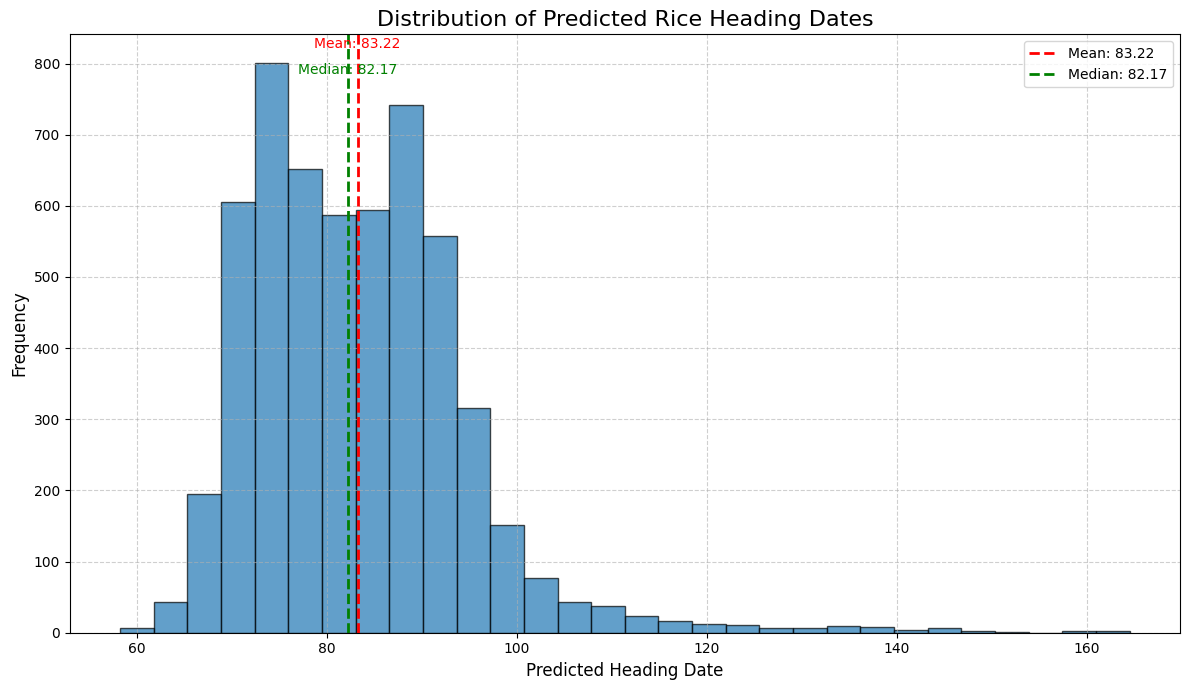

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    # Check if df_y_pred exists (if running in a continuous session)
    df_y_pred = df_y_pred.copy()
except NameError:
    # If not, create a sample DataFrame
    data = {
        'IID': [f'ERS{467753+i}' for i in range(5500)] + [f'SAMN{20901686+i}' for i in range(18)],
        'y_pred_new': np.random.normal(loc=90, scale=15, size=5518)
    }
    data['y_pred_new'][:100] = np.random.uniform(40, 60, size=100)
    data['y_pred_new'][5400:] = np.random.uniform(100, 130, size=118)
    df_y_pred = pd.DataFrame(data)


# --- Calculate key statistics for annotations ---
mean_pred = df_y_pred['y_pred_new'].mean()
median_pred = df_y_pred['y_pred_new'].median()

# --- Create Matplotlib Figure and Axes ---
# Set figure size (approximate Plotly 1200x700 at 100 dpi -> 12x7 inches)
fig, ax = plt.subplots(figsize=(12, 7))

# --- Create Matplotlib Histogram ---
# Use the same number of bins
n_bins = 30
counts, bins, patches = ax.hist(df_y_pred['y_pred_new'], bins=n_bins, edgecolor='k', alpha=0.7)

# --- Add Mean and Median Lines ---
ax.axvline(mean_pred, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_pred:.2f}')
ax.axvline(median_pred, color='green', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')

# --- Add Text Annotations for Mean/Median (Optional - can use legend instead) ---
# Find a suitable y-position for the text annotations (e.g., near the top of the histogram)
# Let's place them just above the highest bin count, or at 95% of the max count
max_freq = counts.max()
text_y = max_freq * 1.02 # Position text slightly above the max bar

# Adjust x position slightly to avoid overlap if lines are close
ax.text(mean_pred, text_y, f'Mean: {mean_pred:.2f}', color='red', ha='center', va='bottom', fontsize=10)
ax.text(median_pred, text_y * 0.98, f'Median: {median_pred:.2f}', color='green', ha='center', va='top', fontsize=10)


# --- Enhance Layout ---
ax.set_title('Distribution of Predicted Rice Heading Dates', fontsize=16)
ax.set_xlabel('Predicted Heading Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Add a legend for the lines (optional if using text annotations)
ax.legend()

# Ensure layout is tight to prevent labels overlapping
fig.tight_layout()

# --- Display the Interactive Visualization ---
fig.show()

## Step 9: Save Visualization as PDF
Let's save our visualization as a PDF file for inclusion in reports or publications. This provides a static version of the plot that can be easily shared.

In [9]:
import os
os.makedirs('output', exist_ok=True)

In [13]:
# --- Export the figure as PDF ---
# PDF is a vector format, dpi affects raster elements and some text rendering
pdf_filepath = "output/rice_heading_date_distribution_predicted.pdf"
fig.savefig(pdf_filepath, dpi=300, bbox_inches='tight') # dpi is less critical for vector
print(f"Figure successfully exported as {pdf_filepath}")

Figure successfully exported as output/rice_heading_date_distribution_predicted.pdf


## Step 10: Export Prediction Results
Now we'll save our predictions to a CSV file for further analysis or sharing with other researchers. This allows the results to be used in other applications or research contexts.

In [11]:
# Save the predictions to a CSV file, including both sample IDs and predicted heading dates
# The resulting CSV can be used for further analysis or shared with collaborators
df_y_pred.to_csv("output/heading_date_predictions_on_new_samples_with_ID_using_ultimate_model.csv", index=False)

print("Predictions saved as 'heading_date_predictions_on_new_samples_with_ID_using_ultimate_model.csv'")

Predictions saved as 'heading_date_predictions_on_new_samples_with_ID_using_ultimate_model.csv'


## Conclusion

This notebook demonstrated the complete workflow for predicting rice heading dates using a pre-trained machine learning model:

1. We loaded the necessary libraries and the pre-trained model
2. We prepared test data containing genetic markers for rice varieties
3. We made predictions using the model
4. We visualized the distribution of predicted heading dates 
5. We exported the results for further use

The distribution visualization shows a range of heading dates from early (40-60 days) to late (100-130 days) varieties, with the majority falling in between. This information is valuable for:
- Plant breeders selecting varieties with specific heading date requirements
- Researchers studying the genetic basis of heading date variation
- Agricultural planners optimizing planting schedules
